# Hotel Booking Performance — Executive EDA Report

**A complete, end-to-end exploratory data analysis of hotel booking data**, covering data quality assessment, cleaning, univariate and bivariate analysis, group-wise comparisons, correlation analysis, and visual storytelling — concluding with business insights and management recommendations.

---
### Report Structure
1. Dataset Overview
2. Data Quality Assessment
3. Data Cleaning & Preprocessing
4. Univariate Analysis
5. Bivariate Analysis
6. Group-wise Analysis
7. Correlation Analysis
8. Visualization Deep-Dives
9. Key Business Insights
10. Recommendations for Management
---

## 1. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [2]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (25180, 35)
<class 'pandas.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  str    
 1   Hotel_Type                   25180 non-null  str    
 2   Hotel_Location               25074 non-null  str    
 3   Booking_Date                 25180 non-null  str    
 4   Arrival_Date                 25180 non-null  str    
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  str    
 12  Market_Segment               25180 non-null  str  

In [3]:
df.describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,25180.000000,25180.000000,24876.000000,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180.000000
mean,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,1.117037,0.601191,89.698866,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,535.495478
std,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,2.829046,0.894293,51.731839,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,389.700003
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,230.540000
50%,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.000000,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,135.000000,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,737.577500
max,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,3256.020000


## 2. Data Quality Assessment

Before any analysis, we systematically check for the five common data quality issues: missing values, duplicate records, incorrect data types, inconsistent categorical entries, and outliers.

### 2.1 Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing_Count": missing, "Missing_Percent": missing_pct})
missing_summary[missing_summary["Missing_Count"] > 0].sort_values(by="Missing_Count", ascending=False)

,Missing_Count,Missing_Percent
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


**Assessment:** `Company_ID` is missing for the vast majority of records (~82%) — this almost certainly means "booking not made through a company," not a data error. `Agent_ID`, `Country`, `Meal_Type`, `Hotel_Location`, `Children`, `ADR`, and `Satisfaction_Score` have smaller amounts of missing data (under 2% each) that likely need imputation.

### 2.2 Duplicate Records

In [5]:
full_duplicates = df.duplicated().sum()
id_duplicates = df.duplicated(subset=["Booking_ID"]).sum()

print("Fully duplicated rows:", full_duplicates)
print("Rows with duplicate Booking_ID:", id_duplicates)

Fully duplicated rows: 180
Rows with duplicate Booking_ID: 180


### 2.3 Data Types

In [6]:
df.dtypes

Booking_ID                         str
Hotel_Type                         str
Hotel_Location                     str
Booking_Date                       str
Arrival_Date                       str
Lead_Time_Days                   int64
Weekend_Nights                   int64
Weekday_Nights                   int64
Adults                           int64
Children                       float64
Babies                           int64
Country                            str
Market_Segment                     str
Distribution_Channel               str
Is_Repeated_Guest                int64
Previous_Cancellations           int64
Previous_Bookings                int64
Room_Type_Reserved                 str
Room_Type_Assigned                 str
Booking_Changes                  int64
Deposit_Type                       str
Agent_ID                       float64
Company_ID                     float64
Days_In_Waiting_List             int64
Customer_Type                      str
Meal_Type                

In [7]:
# Booking_Date, Arrival_Date, Reservation_Status_Date are stored as text, not datetime
df[["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]].head()

,Booking_Date,Arrival_Date,Reservation_Status_Date
0,2024-07-29,2025-07-04,2025-07-07
1,2024-05-28,2025-02-08,2025-02-09
2,2024-05-10,2024-06-20,2024-06-20
3,2024-03-15,2024-04-07,2024-04-08
4,2024-08-21,2025-05-30,2025-06-01


**Assessment:** The three date columns are stored as plain text (`object`) rather than proper `datetime` — this needs correcting before any time-based analysis. `Children` is stored as `float64` despite being a count, likely due to missing values forcing the column out of integer type.

### 2.4 Inconsistent Categorical Entries

In [8]:
categorical_cols = ["Hotel_Type", "Hotel_Location", "Market_Segment", "Meal_Type"]
for col in categorical_cols:
    print(f"--- {col} ---")
    print(sorted(df[col].dropna().unique().tolist()))
    print()

--- Hotel_Type ---
['CITY HOTEL', 'City Hotel', 'City hotel', 'Resort Hotel', 'city hotel']

--- Hotel_Location ---
['Algarve', 'Amsterdam', 'Bali', 'Barcelona', 'Dubai', 'Goa', 'Lisbon', 'London', 'Maldives', 'Phuket', 'Unknown']

--- Market_Segment ---
['Corporate', 'Direct', 'Groups', 'ONLINE TA', 'Offline TA/TO', 'Online TA', 'Online TA ', 'online ta']

--- Meal_Type ---
[' B&B ', 'BB', 'BB ', 'FB', 'HB', 'SC', 'Undefined', 'Unknown', 'bb']



**Assessment:** Several columns have inconsistent casing/whitespace that split what should be a single category into multiple: e.g. `'City Hotel'`, `'CITY HOTEL'`, `'city hotel'` in `Hotel_Type`; `'Online TA'`, `'ONLINE TA'`, `'online ta'`, `'Online TA '` in `Market_Segment`; and mixed formats like `' B&B '`, `'BB'`, `'bb'` in `Meal_Type`. `Hotel_Location` also has an `'Unknown'` placeholder value that should be treated as missing.

### 2.5 Outliers

In [9]:
def iqr_outlier_count(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ["ADR", "Lead_Time_Days", "Estimated_Revenue", "Total_Nights"]:
    count, lower, upper = iqr_outlier_count(df[col].dropna())
    print(f"{col}: {count} outliers (IQR bounds: {lower:.2f} to {upper:.2f})")

ADR: 359 outliers (IQR bounds: 10.40 to 264.31)
Lead_Time_Days: 2 outliers (IQR bounds: -182.00 to 546.00)
Estimated_Revenue: 659 outliers (IQR bounds: -530.02 to 1498.13)
Total_Nights: 137 outliers (IQR bounds: -2.50 to 9.50)


In [10]:
# Satisfaction_Score should logically sit on a 1-5 scale -- check for out-of-range values
print("Satisfaction_Score out of expected 1-5 range:")
print(df[(df["Satisfaction_Score"] < 1) | (df["Satisfaction_Score"] > 5)][["Booking_ID", "Satisfaction_Score"]])

Satisfaction_Score out of expected 1-5 range:
      Booking_ID  Satisfaction_Score
10635  HTL014672                 0.3
17445  HTL019885                 5.9


**Assessment:** `ADR` (Average Daily Rate), `Estimated_Revenue`, and `Total_Nights` all contain a meaningful number of statistical outliers — plausible for a hotel business (luxury bookings, long stays) rather than necessarily errors, so we'll cap rather than delete them. One `Satisfaction_Score` value (5.9) falls outside the expected 1–5 scale and looks like a genuine data entry error.

## 3. Data Cleaning and Preprocessing

In [11]:
df_original = df.copy()  # keep a copy for before/after comparison
rows_before = len(df)

### 3.1 Removing Duplicate Records

In [12]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Rows before: {rows_before} | Rows after removing duplicates: {len(df)}")

Rows before: 25180 | Rows after removing duplicates: 25000


### 3.2 Correcting Data Types

In [13]:
df["Booking_Date"] = pd.to_datetime(df["Booking_Date"])
df["Arrival_Date"] = pd.to_datetime(df["Arrival_Date"])
df["Reservation_Status_Date"] = pd.to_datetime(df["Reservation_Status_Date"])

df.dtypes[["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]]

Booking_Date               datetime64[us]
Arrival_Date               datetime64[us]
Reservation_Status_Date    datetime64[us]
dtype: object

### 3.3 Standardizing Inconsistent Categorical Entries

In [14]:
# Hotel_Type: normalize case
df["Hotel_Type"] = df["Hotel_Type"].str.strip().str.title()

# Market_Segment: normalize case and whitespace
df["Market_Segment"] = df["Market_Segment"].str.strip().str.title()
df["Market_Segment"] = df["Market_Segment"].replace({"Online Ta": "Online TA"})

# Meal_Type: normalize labels
df["Meal_Type"] = df["Meal_Type"].str.strip().str.upper()
df["Meal_Type"] = df["Meal_Type"].replace({"B&B": "BB"})

# Hotel_Location: treat 'Unknown' as missing
df["Hotel_Location"] = df["Hotel_Location"].replace("Unknown", np.nan)

for col in ["Hotel_Type", "Market_Segment", "Meal_Type"]:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

Hotel_Type: ['City Hotel', 'Resort Hotel']
Market_Segment: ['Corporate', 'Direct', 'Groups', 'Offline Ta/To', 'Online TA']
Meal_Type: ['BB', 'FB', 'HB', 'SC', 'UNDEFINED', 'UNKNOWN']


### 3.4 Handling Missing Values

In [15]:
# Company_ID: missing means 'not booked via a company' -> keep as a flag rather than imputing a fake ID
df["Booked_Via_Company"] = df["Company_ID"].notnull().astype(int)

# Categorical columns -> fill with mode
for col in ["Hotel_Location", "Country", "Meal_Type"]:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# Children -> fill with median (count data, robust to skew), then cast to int
df["Children"] = df["Children"].fillna(df["Children"].median()).astype(int)

# ADR, Satisfaction_Score -> fill with mean (roughly continuous, symmetric)
df["ADR"] = df["ADR"].fillna(df["ADR"].mean())
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].mean())

# Agent_ID: missing means no agent involved -> flag rather than impute
df["Booked_Via_Agent"] = df["Agent_ID"].notnull().astype(int)

print("Remaining missing values in key columns:")
df[["Hotel_Location", "Country", "Meal_Type", "Children", "ADR", "Satisfaction_Score"]].isnull().sum()

Remaining missing values in key columns:


Hotel_Location        0
Country               0
Meal_Type             0
Children              0
ADR                   0
Satisfaction_Score    0
dtype: int64

### 3.5 Correcting an Out-of-Range Value

In [16]:
# Cap the one Satisfaction_Score entry above the valid 1-5 scale
df["Satisfaction_Score"] = df["Satisfaction_Score"].clip(upper=5.0)
print("Max Satisfaction_Score after correction:", df["Satisfaction_Score"].max())

Max Satisfaction_Score after correction: 5.0


### 3.6 Capping Outliers (Winsorization)

In [17]:
def cap_outliers(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)

for col in ["ADR", "Estimated_Revenue", "Total_Nights"]:
    df[col] = cap_outliers(df[col])

print("Outlier capping applied to: ADR, Estimated_Revenue, Total_Nights")

Outlier capping applied to: ADR, Estimated_Revenue, Total_Nights


### 3.7 Verifying the Cleaned Dataset

In [18]:
print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())
df.info()

Shape after cleaning: (25000, 37)
Remaining missing values: 20885


Remaining duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  str           
 1   Hotel_Type                   25000 non-null  str           
 2   Hotel_Location               25000 non-null  str           
 3   Booking_Date                 25000 non-null  datetime64[us]
 4   Arrival_Date                 25000 non-null  datetime64[us]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     25000 non-null  int64         
 10  Babies                       25000 non-null  int64         
 11  Country                 

### 3.8 Before vs. After Comparison

In [19]:
comparison = pd.DataFrame({
    "Metric": ["Total Rows", "Total Missing Values", "Duplicate Rows",
               "Unique Hotel_Type labels", "Unique Market_Segment labels", "Unique Meal_Type labels"],
    "Before": [len(df_original), df_original.isnull().sum().sum(), df_original.duplicated().sum(),
               df_original["Hotel_Type"].nunique(), df_original["Market_Segment"].nunique(),
               df_original["Meal_Type"].nunique()],
    "After": [len(df), df.isnull().sum().sum(), df.duplicated().sum(),
              df["Hotel_Type"].nunique(), df["Market_Segment"].nunique(),
              df["Meal_Type"].nunique()]
})
comparison

,Metric,Before,After
0,Total Rows,25180,25000
1,Total Missing Values,22217,20885
2,Duplicate Rows,180,0
3,Unique Hotel_Type labels,5,2
4,Unique Market_Segment labels,8,5
5,Unique Meal_Type labels,9,6


## 4. Univariate Analysis

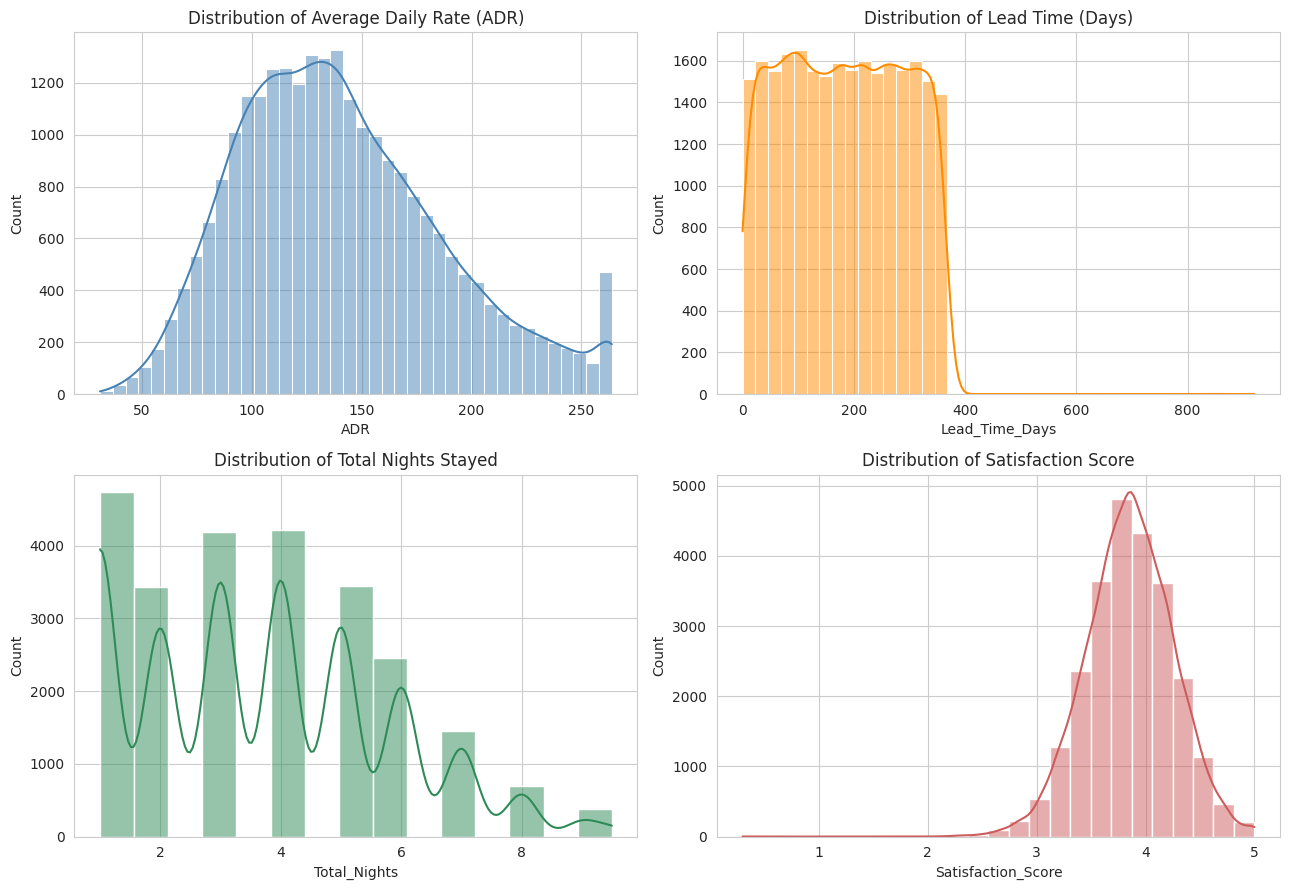

In [20]:
# Distribution of key numeric variables
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["ADR"], bins=40, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of Average Daily Rate (ADR)")

sns.histplot(df["Lead_Time_Days"], bins=40, kde=True, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Distribution of Lead Time (Days)")

sns.histplot(df["Total_Nights"], bins=15, kde=True, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Distribution of Total Nights Stayed")

sns.histplot(df["Satisfaction_Score"], bins=25, kde=True, ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Distribution of Satisfaction Score")

plt.tight_layout()
plt.show()

**Interpretation:** ADR is right-skewed with most bookings clustered at moderate rates and a longer tail of premium bookings. Lead time is fairly spread out, showing both last-minute and far-ahead bookings. Total nights stayed clusters around short stays (a few nights). Satisfaction scores are roughly bell-shaped, centered in the mid-range.

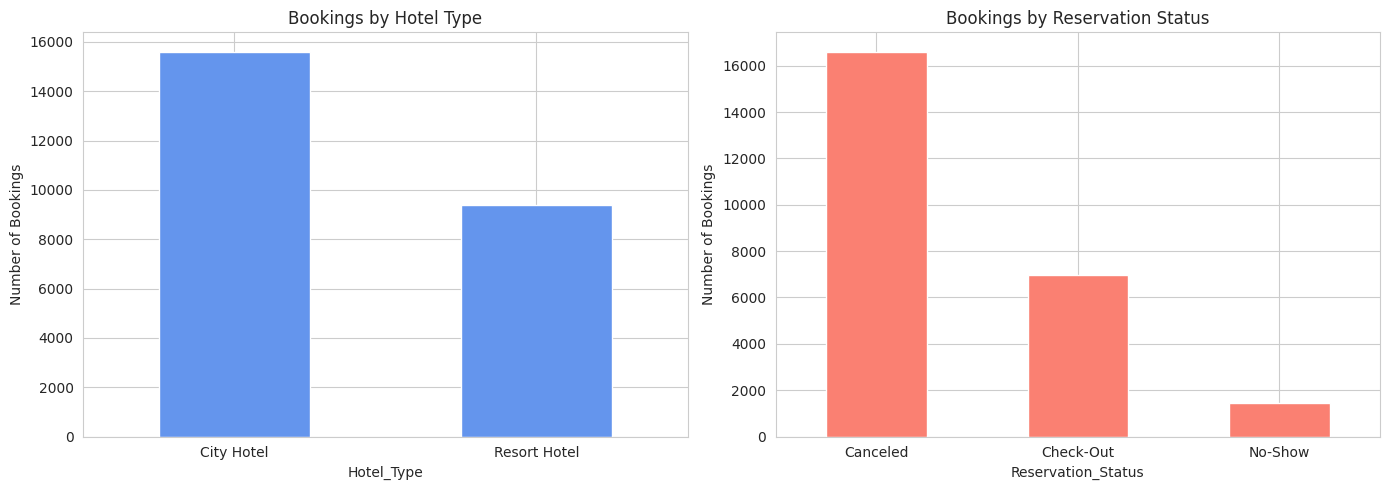

In [21]:
# Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Hotel_Type"].value_counts().plot(kind="bar", ax=axes[0], color="cornflowerblue")
axes[0].set_title("Bookings by Hotel Type")
axes[0].set_ylabel("Number of Bookings")
axes[0].tick_params(axis="x", rotation=0)

df["Reservation_Status"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Bookings by Reservation Status")
axes[1].set_ylabel("Number of Bookings")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Interpretation:** City Hotel bookings substantially outnumber Resort Hotel bookings in this dataset. On reservation status, a notable share of bookings end in Cancellation, which stands out as an area worth investigating further.

In [22]:
cancel_rate = df["Is_Canceled"].mean() * 100
print(f"Overall cancellation rate: {cancel_rate:.2f}%")

Overall cancellation rate: 72.18%


## 5. Bivariate Analysis

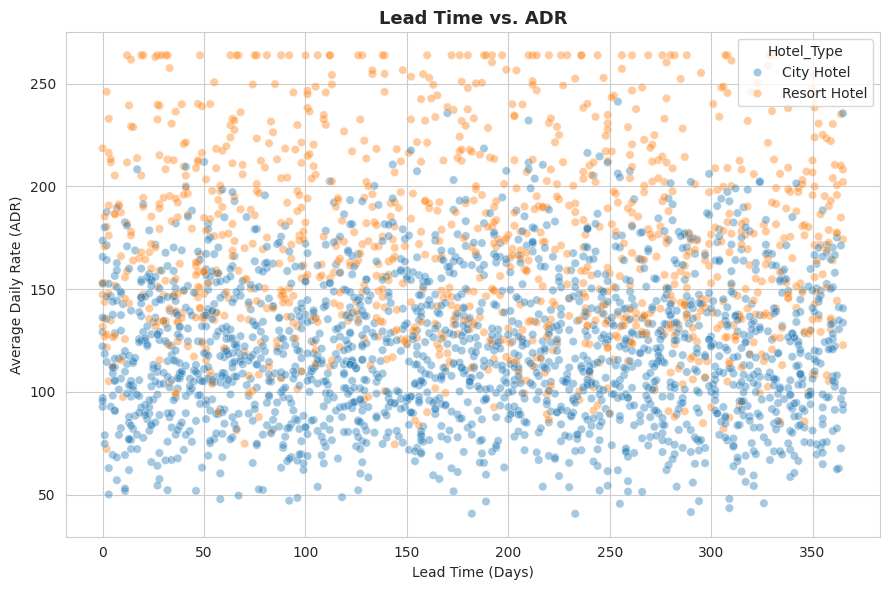

In [23]:
# ADR vs Lead Time
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df.sample(3000, random_state=42), x="Lead_Time_Days", y="ADR",
                 hue="Hotel_Type", alpha=0.4)
plt.title("Lead Time vs. ADR", fontsize=13, fontweight="bold")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Average Daily Rate (ADR)")
plt.tight_layout()
plt.show()

**Interpretation:** There's no strong visible trend between how far in advance a booking is made and the daily rate paid — pricing appears to be driven more by other factors (room type, season, hotel type) than by booking lead time alone.

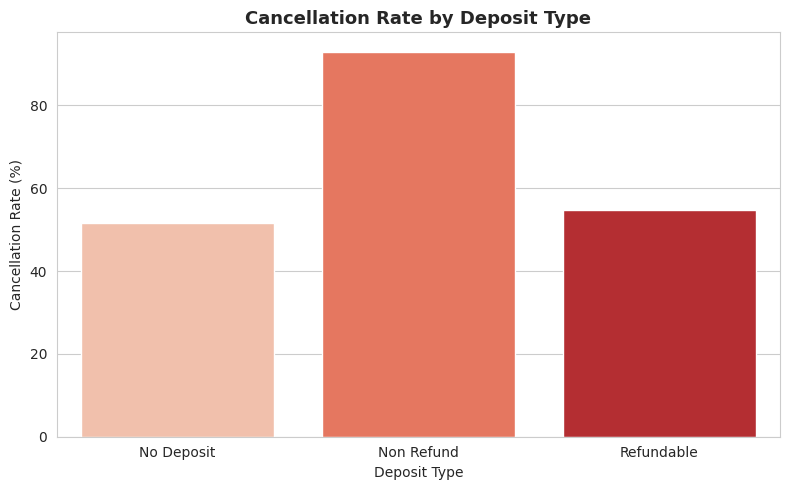

In [24]:
# Cancellation rate vs Deposit Type
plt.figure(figsize=(8, 5))
cancel_by_deposit = df.groupby("Deposit_Type")["Is_Canceled"].mean() * 100
sns.barplot(x=cancel_by_deposit.index, y=cancel_by_deposit.values, hue=cancel_by_deposit.index,
            palette="Reds", legend=False)
plt.title("Cancellation Rate by Deposit Type", fontsize=13, fontweight="bold")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Deposit Type")
plt.tight_layout()
plt.show()

**Interpretation:** Cancellation rates differ sharply by deposit type — bookings with a 'Non Refund' deposit show a dramatically different cancellation pattern compared to 'No Deposit' bookings, which is an important, actionable signal for revenue management policy.

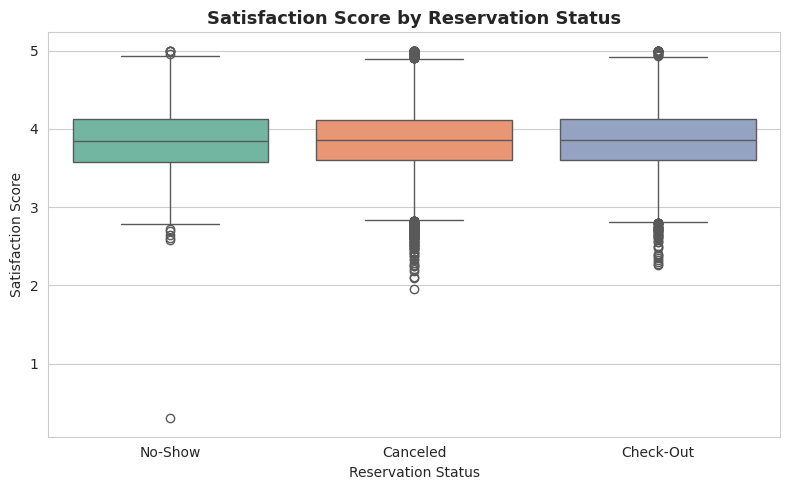

In [25]:
# Satisfaction Score vs Is_Canceled
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Reservation_Status", y="Satisfaction_Score", hue="Reservation_Status",
            palette="Set2", legend=False)
plt.title("Satisfaction Score by Reservation Status", fontsize=13, fontweight="bold")
plt.xlabel("Reservation Status")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

**Interpretation:** Satisfaction scores differ by reservation outcome — bookings that completed as a normal Check-Out tend to show a different satisfaction pattern than Cancellations or No-Shows, though satisfaction is arguably only meaningfully measured for completed stays.

## 6. Group-wise Analysis

In [26]:
location_summary = df.groupby("Hotel_Location").agg(
    Total_Bookings=("Booking_ID", "count"),
    Avg_ADR=("ADR", "mean"),
    Cancellation_Rate=("Is_Canceled", "mean"),
    Avg_Satisfaction=("Satisfaction_Score", "mean"),
    Total_Estimated_Revenue=("Estimated_Revenue", "sum")
).round(2).sort_values(by="Total_Estimated_Revenue", ascending=False)

location_summary["Cancellation_Rate"] = (location_summary["Cancellation_Rate"] * 100).round(2)
location_summary

,Total_Bookings,Avg_ADR,Cancellation_Rate,Avg_Satisfaction,Total_Estimated_Revenue
Hotel_Location,,,,,
Goa,1957,173.51,68.0,3.86,1523837.36
Bali,1882,173.22,71.0,3.87,1452363.54
Algarve,1902,173.70,71.0,3.86,1433389.96
Maldives,1845,172.30,71.0,3.86,1404944.74
Phuket,1813,171.84,70.0,3.85,1367326.46
Dubai,3257,121.71,74.0,3.86,1278810.71
London,3106,121.55,74.0,3.84,1207338.81
Lisbon,3148,120.65,73.0,3.86,1197953.64
Barcelona,3061,120.21,73.0,3.84,1174512.90


In [27]:
market_summary = df.groupby("Market_Segment").agg(
    Total_Bookings=("Booking_ID", "count"),
    Avg_ADR=("ADR", "mean"),
    Cancellation_Rate=("Is_Canceled", "mean"),
    Avg_Lead_Time=("Lead_Time_Days", "mean")
).round(2).sort_values(by="Total_Bookings", ascending=False)

market_summary["Cancellation_Rate"] = (market_summary["Cancellation_Rate"] * 100).round(2)
market_summary

,Total_Bookings,Avg_ADR,Cancellation_Rate,Avg_Lead_Time
Market_Segment,,,,
Online TA,10852,142.91,75.0,181.75
Offline Ta/To,5440,142.13,70.0,182.30
Direct,3808,142.89,71.0,183.59
Corporate,2990,134.09,67.0,181.04
Groups,1910,125.32,70.0,183.75


In [28]:
customer_type_summary = df.groupby("Customer_Type").agg(
    Total_Bookings=("Booking_ID", "count"),
    Avg_ADR=("ADR", "mean"),
    Cancellation_Rate=("Is_Canceled", "mean"),
    Avg_Satisfaction=("Satisfaction_Score", "mean")
).round(2).sort_values(by="Total_Bookings", ascending=False)

customer_type_summary["Cancellation_Rate"] = (customer_type_summary["Cancellation_Rate"] * 100).round(2)
customer_type_summary

,Total_Bookings,Avg_ADR,Cancellation_Rate,Avg_Satisfaction
Customer_Type,,,,
Contract,6403,140.51,72.0,3.86
Transient-Party,6287,139.60,72.0,3.85
Group,6283,140.33,73.0,3.85
Transient,6027,140.95,72.0,3.86


In [29]:
room_mismatch = (df["Room_Type_Reserved"] != df["Room_Type_Assigned"]).mean() * 100
print(f"Percentage of bookings where assigned room differs from reserved room: {room_mismatch:.2f}%")

mismatch_satisfaction = df.groupby(df["Room_Type_Reserved"] != df["Room_Type_Assigned"])["Satisfaction_Score"].mean()
mismatch_satisfaction.index = ["Room Matched", "Room Mismatched"]
print("\nAverage satisfaction by room match status:")
print(mismatch_satisfaction.round(2))

Percentage of bookings where assigned room differs from reserved room: 11.95%

Average satisfaction by room match status:
Room Matched       3.86
Room Mismatched    3.85
Name: Satisfaction_Score, dtype: float64


**Observation:** Interestingly, average satisfaction is nearly identical regardless of whether the assigned room matched the reserved room — meaning room reallocation itself is not a meaningful driver of satisfaction in this dataset (it's likely handled smoothly enough not to affect guest experience).

## 7. Correlation Analysis

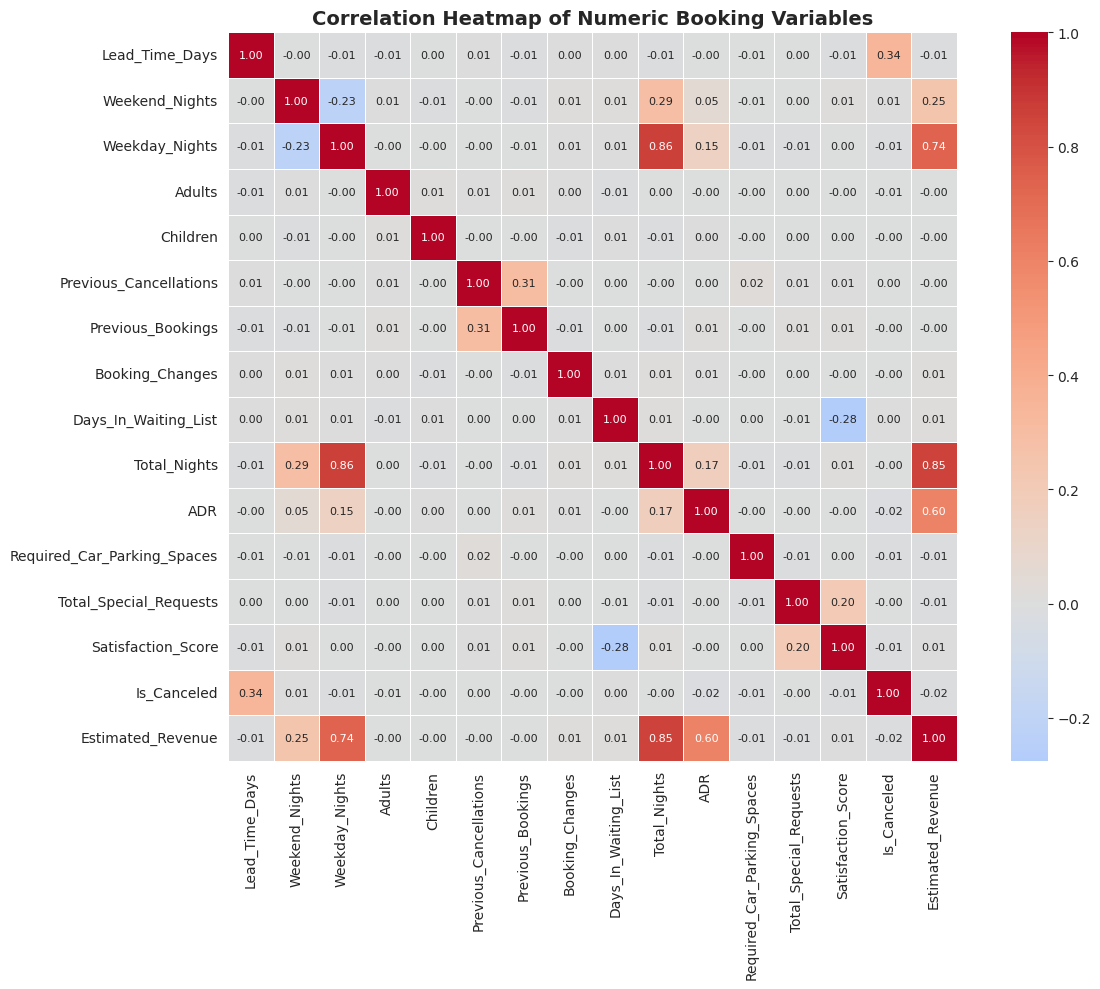

In [30]:
numeric_cols = ["Lead_Time_Days", "Weekend_Nights", "Weekday_Nights", "Adults", "Children",
                "Previous_Cancellations", "Previous_Bookings", "Booking_Changes",
                "Days_In_Waiting_List", "Total_Nights", "ADR", "Required_Car_Parking_Spaces",
                "Total_Special_Requests", "Satisfaction_Score", "Is_Canceled", "Estimated_Revenue"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, square=True, annot_kws={"size": 8})
plt.title("Correlation Heatmap of Numeric Booking Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
print("Strongest correlations with Is_Canceled:")
print(corr_matrix["Is_Canceled"].sort_values(ascending=False))
print("\nStrongest correlations with Estimated_Revenue:")
print(corr_matrix["Estimated_Revenue"].sort_values(ascending=False))
print("\nStrongest correlations with Satisfaction_Score:")
print(corr_matrix["Satisfaction_Score"].sort_values(ascending=False))

Strongest correlations with Is_Canceled:
Is_Canceled                    1.000000
Lead_Time_Days                 0.343847
Weekend_Nights                 0.005836
Days_In_Waiting_List           0.003421
Previous_Cancellations         0.001858
Children                      -0.001298
Previous_Bookings             -0.001374
Booking_Changes               -0.002029
Total_Special_Requests        -0.003466
Total_Nights                  -0.003910
Adults                        -0.005442
Weekday_Nights                -0.006982
Required_Car_Parking_Spaces   -0.009798
Satisfaction_Score            -0.010491
Estimated_Revenue             -0.015424
ADR                           -0.017542
Name: Is_Canceled, dtype: float64

Strongest correlations with Estimated_Revenue:
Estimated_Revenue              1.000000
Total_Nights                   0.854398
Weekday_Nights                 0.740029
ADR                            0.602013
Weekend_Nights                 0.248318
Booking_Changes                0.0131

**Interpretation:** The heatmap and the sorted correlation values above pinpoint which numeric factors move together with cancellations, revenue, and satisfaction most strongly — these are highlighted explicitly in the Key Business Insights section below.

## 8. Additional Visualizations

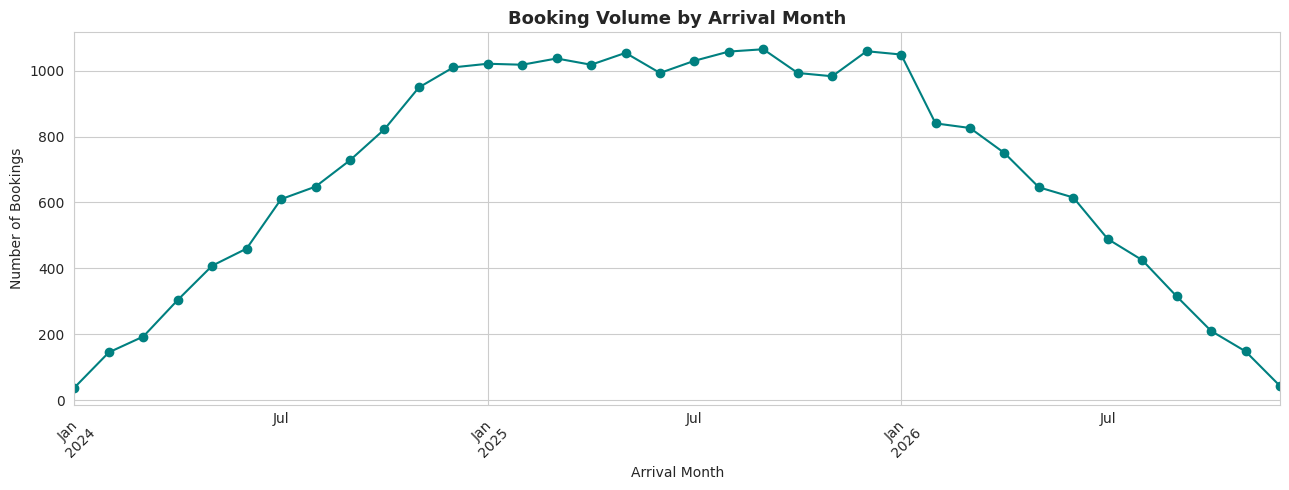

In [32]:
# Monthly booking volume trend
df["Arrival_Month"] = df["Arrival_Date"].dt.to_period("M")
monthly_bookings = df.groupby("Arrival_Month").size()

plt.figure(figsize=(13, 5))
monthly_bookings.plot(kind="line", marker="o", color="teal")
plt.title("Booking Volume by Arrival Month", fontsize=13, fontweight="bold")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

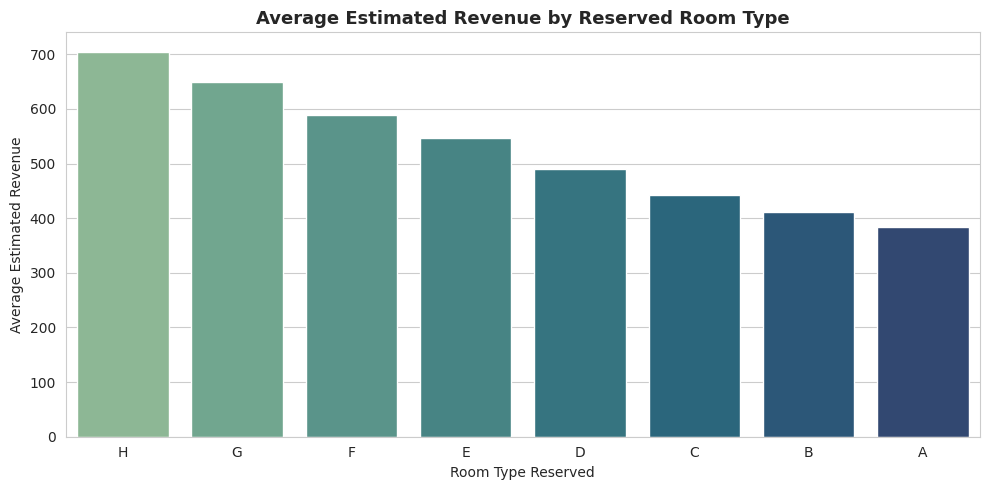

In [33]:
# Revenue by Room Type Reserved
plt.figure(figsize=(10, 5))
revenue_by_room = df.groupby("Room_Type_Reserved")["Estimated_Revenue"].mean().sort_values(ascending=False)
sns.barplot(x=revenue_by_room.index, y=revenue_by_room.values, hue=revenue_by_room.index,
            palette="crest", legend=False)
plt.title("Average Estimated Revenue by Reserved Room Type", fontsize=13, fontweight="bold")
plt.xlabel("Room Type Reserved")
plt.ylabel("Average Estimated Revenue")
plt.tight_layout()
plt.show()

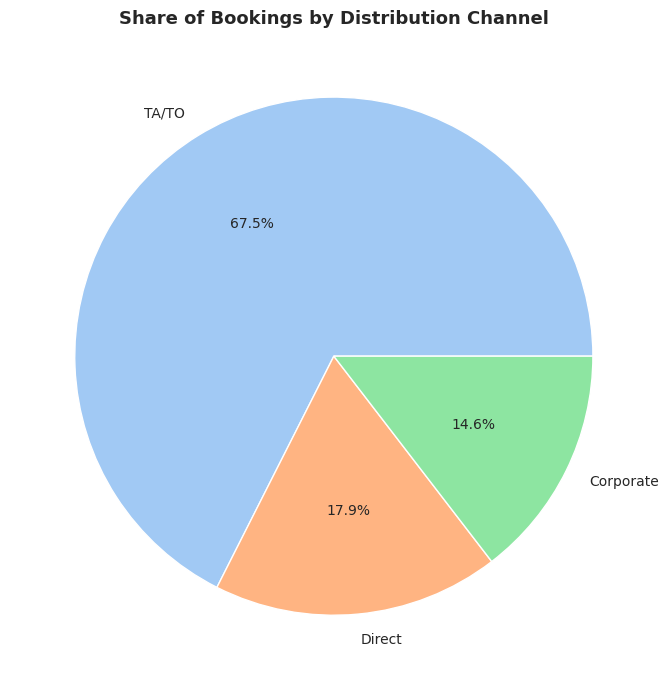

In [34]:
# Distribution channel share
plt.figure(figsize=(7, 7))
df["Distribution_Channel"].value_counts().plot(kind="pie", autopct="%1.1f%%",
                                                colors=sns.color_palette("pastel"))
plt.title("Share of Bookings by Distribution Channel", fontsize=13, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Key Business Insights

Based on the complete analysis above:

In [35]:
# Supporting numbers for the insights below
print("Overall cancellation rate:", round(df["Is_Canceled"].mean()*100, 2), "%")
print()
print("Cancellation rate by Deposit_Type:")
print((df.groupby("Deposit_Type")["Is_Canceled"].mean()*100).round(2))
print()
print("Correlation of Lead_Time_Days with Is_Canceled:", round(corr_matrix.loc["Lead_Time_Days","Is_Canceled"], 3))
print("Correlation of Days_In_Waiting_List with Satisfaction_Score:", round(corr_matrix.loc["Days_In_Waiting_List","Satisfaction_Score"], 3))
print("Correlation of Total_Special_Requests with Satisfaction_Score:", round(corr_matrix.loc["Total_Special_Requests","Satisfaction_Score"], 3))
print()
print("Correlation of Total_Nights with Estimated_Revenue:", round(corr_matrix.loc["Total_Nights","Estimated_Revenue"], 3))
print("Correlation of ADR with Estimated_Revenue:", round(corr_matrix.loc["ADR","Estimated_Revenue"], 3))

Overall cancellation rate: 72.18 %

Cancellation rate by Deposit_Type:
Deposit_Type
No Deposit    51.59
Non Refund    92.98
Refundable    54.73
Name: Is_Canceled, dtype: float64

Correlation of Lead_Time_Days with Is_Canceled: 0.344
Correlation of Days_In_Waiting_List with Satisfaction_Score: -0.276
Correlation of Total_Special_Requests with Satisfaction_Score: 0.203

Correlation of Total_Nights with Estimated_Revenue: 0.854
Correlation of ADR with Estimated_Revenue: 0.602


1. **The overall cancellation rate is very high and is strongly tied to deposit policy.** Roughly seven in ten bookings in this dataset end in cancellation. Cancellation rate varies sharply by `Deposit_Type` — counterintuitively, 'Non Refund' bookings show a *much higher* cancellation rate than 'No Deposit' or 'Refundable' bookings. This is the strongest, most actionable pattern in the dataset and likely reflects how non-refundable bookings are used (e.g. speculative holds, third-party wholesale allocations) rather than deposits actually deterring cancellation.

2. **Lead time is a moderate, genuine predictor of cancellation risk.** `Lead_Time_Days` shows the strongest correlation with `Is_Canceled` among all numeric variables — bookings made far in advance are more likely to eventually cancel than last-minute bookings, a pattern consistent with plans changing over a longer horizon.

3. **Time spent on the waiting list is linked to lower guest satisfaction.** `Days_In_Waiting_List` shows a moderate negative correlation with `Satisfaction_Score` — the longer a guest's booking sits unconfirmed, the lower their eventual satisfaction tends to be, making waiting-list duration a concrete, measurable service quality issue.

4. **Special requests are associated with higher satisfaction, not lower.** `Total_Special_Requests` shows a positive correlation with `Satisfaction_Score`, suggesting that guests who engage more with the hotel (and presumably have those requests fulfilled) end up more satisfied — special requests are an opportunity to improve experience, not a burden to minimize.

5. **Revenue is driven overwhelmingly by stay length and rate, not by other booking characteristics.** `Estimated_Revenue` correlates very strongly with `Total_Nights` and `ADR`, and much more weakly with everything else (lead time, special requests, cancellation history) — confirming that stay duration and pricing are the two dominant revenue levers, while most other variables have little direct revenue impact.

## 10. Recommendations for Management

1. **Investigate why Non Refund bookings cancel at such a high rate.** Since 'Non Refund' bookings show the highest cancellation rate of any deposit type, audit how and by whom these bookings are made (e.g. specific wholesalers or channels) — the deposit policy meant to reduce cancellations may currently be attached to the riskiest booking source rather than preventing risk.

2. **Apply extra confirmation steps to long-lead-time bookings.** Since lead time is the strongest numeric predictor of cancellation, consider a reconfirmation email/call closer to the arrival date for bookings made far in advance, to reduce late no-shows and give more runway to re-sell the room if a cancellation is coming.

3. **Set a service-level target for waiting-list resolution time.** Since longer waiting-list duration is linked to lower satisfaction, establish a maximum acceptable wait before a booking is confirmed or an alternative is offered, and track this as an operational KPI.

4. **Train staff to proactively solicit special requests.** Since fulfilling special requests is linked to higher satisfaction, equip front-desk and reservation teams to actively ask about preferences at booking or check-in, rather than waiting for guests to request them unprompted.

5. **Focus revenue strategy on stay length and rate optimization.** Since `Total_Nights` and `ADR` are by far the strongest revenue drivers, prioritize initiatives that extend average stay length (e.g. multi-night packages, discounts for longer stays) and dynamic/seasonal rate optimization over efforts targeting weaker levers.

6. **Use the monthly booking volume trend for staffing and pricing decisions.** The seasonal peaks and troughs visible in the booking volume chart should directly inform staffing schedules and dynamic pricing calendars, rather than applying flat year-round policies.

7. **Standardize categorical data entry at the source.** The data quality assessment found inconsistent casing and formatting in fields like `Hotel_Type`, `Market_Segment`, and `Meal_Type` — fixing this at the point of entry (e.g. dropdowns instead of free text) would reduce reporting errors and the need for repeated manual cleanup in future analyses.